In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import re
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score,
from wordcloud import WordCloud
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.utils import to_categorical

<h3> Data Loading

In [14]:
df = pd.read_csv("eng_tweet.csv")

df.head()

,Unnamed: 0,tweet,sentiment
0,0,Tried the air quality for a while to see if it...,neutral
1,1,The marketplace wass low; I can't stand it. Cu...,negative
2,2,@artist interview update noted. 🕒 #Breaking #News,neutral
3,3,@support Tried the friends for a while to see ...,neutral
4,4,@company Absolutely fantastic! 🔥 #Weekend,positive


Data Exploration

In [15]:
df.shape

(39808, 3)

In [16]:
df.isna().sum() #checks for rows with empty values

Unnamed: 0    0
tweet         0
sentiment     0
dtype: int64

In [17]:
new = df.drop(["Unnamed: 0"], axis=1)


In [18]:
new.isna().sum()

tweet        0
sentiment    0
dtype: int64

In [19]:
new.sentiment.value_counts() # accounts for the total number of each sentiment in the dataset

sentiment
positive    14082
neutral     13224
negative    12502
Name: count, dtype: int64

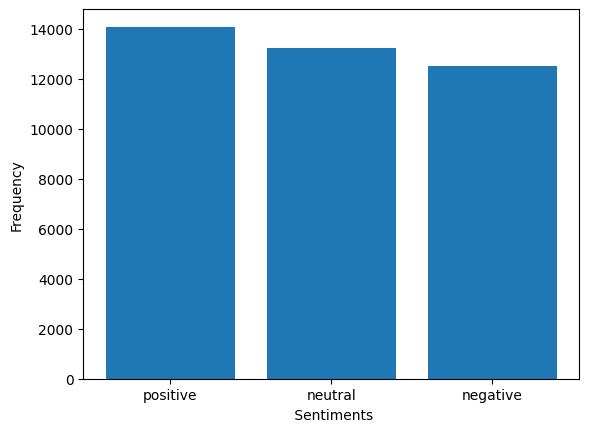

In [20]:
sent = new['sentiment'].value_counts()

plt.bar(sent.index, sent.values)
plt.xlabel(" Sentiments")
plt.ylabel("Frequency")
plt.show()

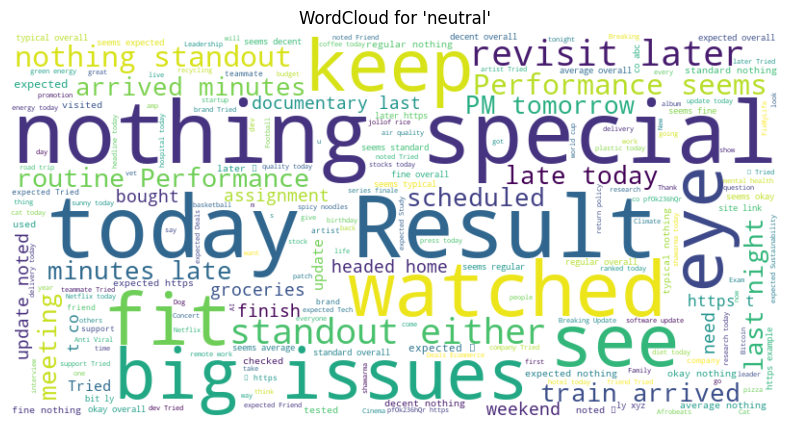

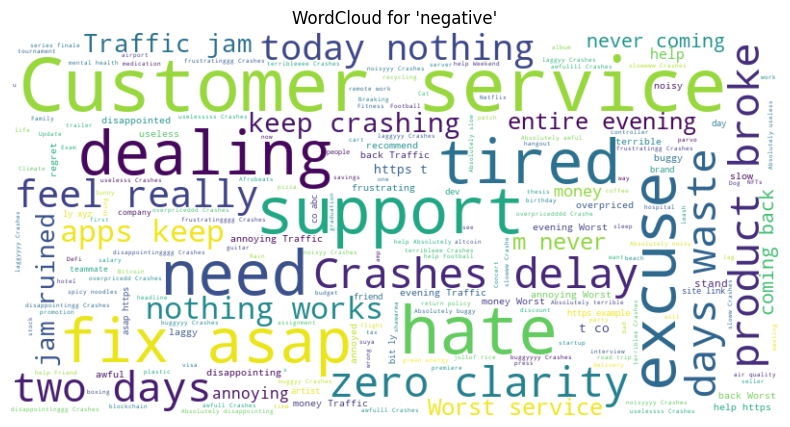

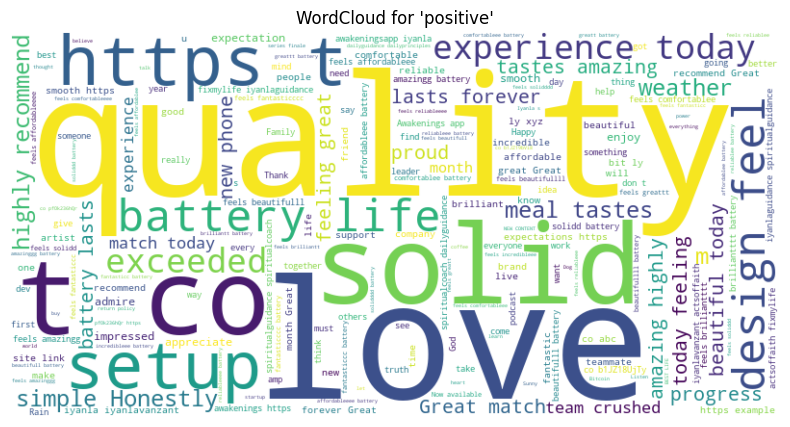

In [50]:
for label in new["sentiment"].unique():
    text = " ".join(new[new["sentiment"] == label]["tweet"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"WordCloud for '{label}'")
    plt.axis("off")
    plt.show()

<h3> Data Preprocessing

- Loading large spacy english pretrained pipeline which will be used for the text preproceesing 

In [21]:
nlp=spacy.load("en_core_web_lg")

- define a function to remove stopwords and punctuatons, also tokenizing , lowercase conversion and lemmitizing the words.

In [22]:
def preprocess_text(text):
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_.lower())

    return " ".join(filtered_tokens)


In [23]:
new['preprocessed_tweet'] = new.tweet.apply(preprocess_text) #tweets preprocessing

In [24]:
new.head(10)

,tweet,sentiment,preprocessed_tweet
0,Tried the air quality for a while to see if it...,neutral,try air quality fit routine performance typica...
1,The marketplace wass low; I can't stand it. Cu...,negative,marketplace wass low stand customer service id...
2,@artist interview update noted. 🕒 #Breaking #News,neutral,interview update note 🕒 break news
3,@support Tried the friends for a while to see ...,neutral,try friend fit routine performance typical o...
4,@company Absolutely fantastic! 🔥 #Weekend,positive,absolutely fantastic 🔥 weekend
5,Tried the Zapier for a while to see if it fits...,neutral,try zapier fit routine performance typical ove...
6,@friend Absolutely reliable! 👍 #Dogs #Cats,positive,absolutely reliable 👍 dog cat
7,I tested the exam today. Results were standard...,neutral,test exam today result standard special expect...
8,I recommend this shawarma; the quality is beau...,positive,recommend shawarma quality beautiful experienc...
9,I tried the tennis today. Results were regular...,neutral,try tennis today result regular special expect...


<h3> Handling Class Imbalance </h3> <br>
Since there is imbalance in the labels, Oversampling method will be used to balance the dataset which involves populating the minority labels to be equal to the majority label.

In [25]:
# class count
count_class_positive, count_class_neutral, count_class_negative = new.sentiment.value_counts()
count_class_positive, count_class_neutral, count_class_negative

(14082, 13224, 12502)

In [26]:
df_class_negative = new[new['sentiment']=="negative"]
df_class_neutral = new[new['sentiment']== "neutral"]
df_class_positive = new[new['sentiment']== "positive"]

In [27]:
df_class_neutral_over = df_class_neutral.sample(count_class_positive, replace=True)
df_class_negative_over = df_class_negative.sample(count_class_positive, replace=True)

df_test_over = pd.concat([df_class_negative_over,df_class_neutral_over,df_class_positive], axis=0)

print(df_test_over.sentiment.value_counts())

sentiment
negative    14082
neutral     14082
positive    14082
Name: count, dtype: int64


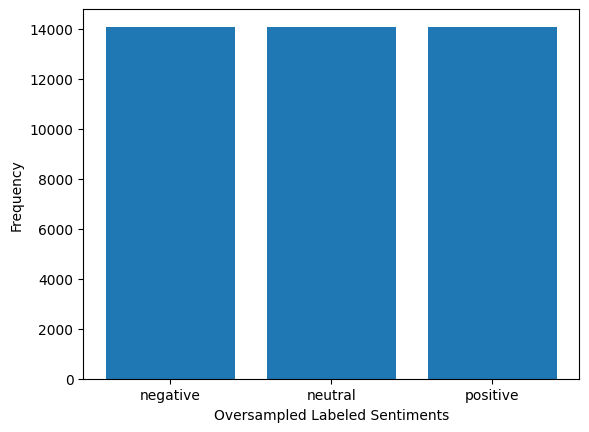

In [28]:
classes_instances = df_test_over['sentiment'].value_counts()


plt.bar(classes_instances.index, classes_instances.values)
plt.xlabel("Oversampled Labeled Sentiments")
plt.ylabel("Frequency")
plt.show()

In [ ]:
mapping = {'negative':0, 'neutral':1, 'positive':2}
df_test_over['new_label'] = df_test_over['sentiment'].map(mapping)

In [30]:
df_test_over.new_label.value_counts()

new_label
0    14082
1    14082
2    14082
Name: count, dtype: int64

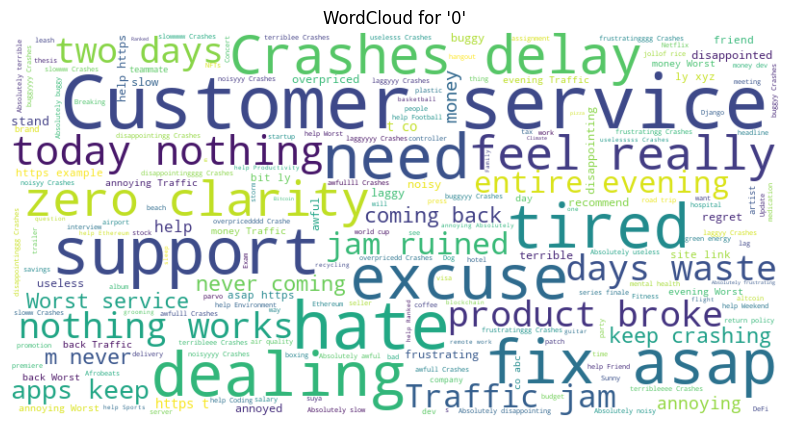

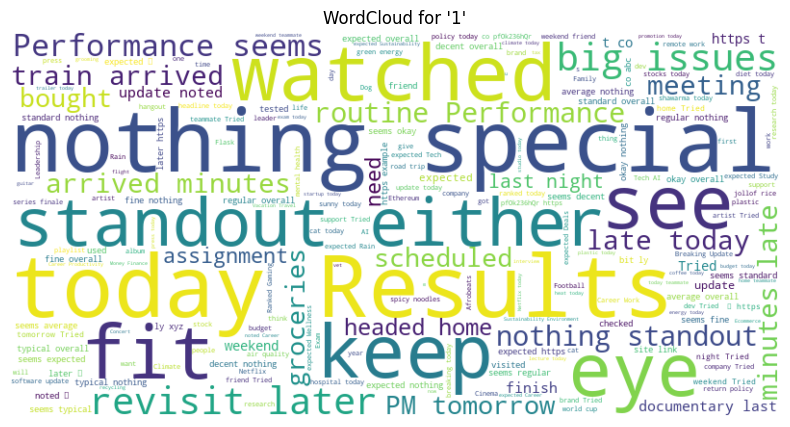

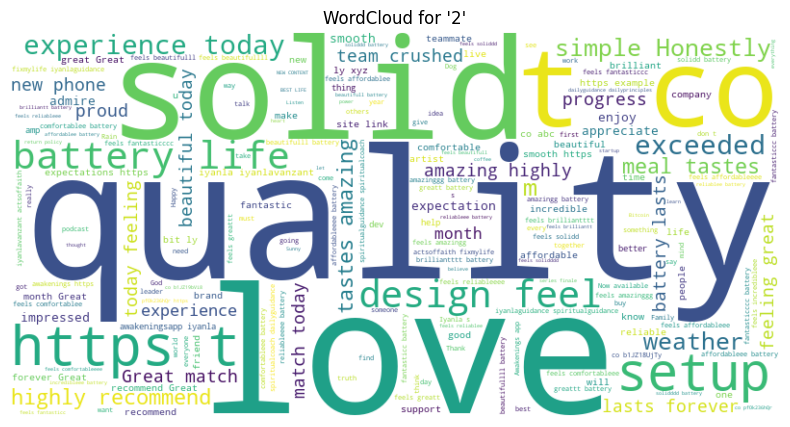

In [52]:
for label in df_test_over["new_label"].unique():
    text = " ".join(df_test_over[df_test_over["new_label"] == label]["tweet"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"WordCloud for '{label}'")
    plt.axis("off")
    plt.show()

0: negative, 1: neutral, 2: positive

- CNN Model 

In [ ]:
# 1. Tokenize & pad sequences
texts = df_test_over['clean_text'].tolist()
labels = df_test_over['label'].values

# Parameters
max_vocab_size = 10000
max_seq_length = 50  # adjust based on sentence length distribution
embedding_dim = 100
num_classes = len(np.unique(labels))

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_seq_length, padding='post', truncating='post')

- Convert label to one hot and  Split data

In [ ]:
labels_cat = to_categorical(labels, num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels_cat, test_size=0.2, random_state=42, stratify=labels)

- CNN

In [ ]:
def create_cnn_model():
    model = Sequential([
        Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_length),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [37]:
model2 = create_cnn_model()

# Train
history = model2.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluate
loss, accuracy = model2.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10


476/476 ━━━━━━━━━━━━━━━━━━━━ 85s 164ms/step - accuracy: 0.9443 - loss: 0.1595 - val_accuracy: 0.9763 - val_loss: 0.0621
Epoch 2/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 73s 154ms/step - accuracy: 0.9902 - loss: 0.0317 - val_accuracy: 0.9775 - val_loss: 0.0680
Epoch 3/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 94s 180ms/step - accuracy: 0.9981 - loss: 0.0078 - val_accuracy: 0.9769 - val_loss: 0.0906
Epoch 4/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 77s 161ms/step - accuracy: 0.9993 - loss: 0.0027 - val_accuracy: 0.9751 - val_loss: 0.1048
Epoch 5/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 77s 149ms/step - accuracy: 0.9992 - loss: 0.0022 - val_accuracy: 0.9754 - val_loss: 0.1217
Epoch 6/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 83s 151ms/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 0.9769 - val_loss: 0.1198
Epoch 7/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 77s 139ms/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 0.9754 - val_loss: 0.1323
Epoch 8/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 132s 239ms/step - accuracy: 0.9993 - loss: 0.0028 - va

In [42]:
samples = [
    "I really enjoyed the food today",
    "This is the worst service I’ve ever seen",
    "I feel okay, nothing special happened",
    "The movie was fantastic, I loved every part",
    "I am disappointed with the results",
    "The weather is amazing, perfect for a walk",
    "I hate waiting in long lines",
    "That performance was average, nothing great",
    "I love how supportive my friends are",
    "This product is terrible, waste of money",
    "I feel neutral about the decision",
    "The new update is wonderful, great job!",
    "I can’t stand the noise in this place",
    "That’s fine, I don’t really mind",
    "The trip was exciting and full of fun",
    "The meeting went poorly, such a waste of time",
    "I feel calm, nothing unusual today",
    "Excellent service, I’m very impressed",
    "The package arrived late, very frustrating",
    "It’s just an ordinary day, nothing special"
]


In [43]:
def dl_predict(model, texts):
    clean_texts = [preprocess_text(t) for t in texts]
    seqs = tokenizer.texts_to_sequences(clean_texts)
    padded = pad_sequences(seqs, maxlen=max_seq_length, padding='post', truncating='post')
    preds = model.predict(padded, verbose=0)
    classes = np.argmax(preds, axis=1)
    return [label_map[c] for c in classes]

# Label map from your code (adjust if needed)
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Predict with CNN (model2)
cnn_preds = dl_predict(model2, samples)
print("\nCNN Predictions:")
for text, pred in zip(samples, cnn_preds):
    print(f"{text} -> {pred}")


CNN Predictions:
I really enjoyed the food today -> positive
This is the worst service I’ve ever seen -> negative
I feel okay, nothing special happened -> neutral
The movie was fantastic, I loved every part -> positive
I am disappointed with the results -> negative
The weather is amazing, perfect for a walk -> positive
I hate waiting in long lines -> negative
That performance was average, nothing great -> neutral
I love how supportive my friends are -> positive
This product is terrible, waste of money -> negative
I feel neutral about the decision -> neutral
The new update is wonderful, great job! -> positive
I can’t stand the noise in this place -> neutral
That’s fine, I don’t really mind -> neutral
The trip was exciting and full of fun -> positive
The meeting went poorly, such a waste of time -> negative
I feel calm, nothing unusual today -> positive
Excellent service, I’m very impressed -> neutral
The package arrived late, very frustrating -> neutral
It’s just an ordinary day, nothi

In [44]:
y_prred = np.argmax(model2.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true, y_prred, target_names=['negative','neutral','positive']))

265/265 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step
              precision    recall  f1-score   support

    negative       0.99      0.98      0.98      2816
     neutral       0.97      0.97      0.97      2817
    positive       0.97      0.97      0.97      2817

    accuracy                           0.98      8450
   macro avg       0.98      0.98      0.98      8450
weighted avg       0.98      0.98      0.98      8450



In [54]:
model2.save('English_model.keras')